## Phase 1: Understand the problem and data

### Step 1 — Load and explore. 

In [1]:
import os

BASE_PATH = "/kaggle/input/competitions/store-sales-time-series-forecasting"

os.listdir(BASE_PATH)

['oil.csv',
 'sample_submission.csv',
 'holidays_events.csv',
 'stores.csv',
 'train.csv',
 'test.csv',
 'transactions.csv']

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


train = pd.read_csv(f"{BASE_PATH}/train.csv")
test = pd.read_csv(f"{BASE_PATH}/test.csv")
stores = pd.read_csv(f"{BASE_PATH}/stores.csv")
oil = pd.read_csv(f"{BASE_PATH}/oil.csv")
holidays = pd.read_csv(f"{BASE_PATH}/holidays_events.csv")
transactions = pd.read_csv(f"{BASE_PATH}/transactions.csv")
sample_submission = pd.read_csv(f"{BASE_PATH}/sample_submission.csv")

In [3]:
dataframes = {
    "train": train,
    "test": test,
    "stores": stores,
    "oil": oil,
    "holidays": holidays,
    "transactions": transactions,
}

for name, df in dataframes.items():
    print("=" * 40)
    print(name.upper())
    print("Shape:", df.shape)
    display(df.head(3))

TRAIN
Shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0


TEST
Shape: (28512, 5)


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2


STORES
Shape: (54, 5)


...

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97


HOLIDAYS
Shape: (350, 6)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False


TRANSACTIONS
Shape: (83488, 3)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358


In [4]:
# check out the date range
print(f"Train data range: {train['date'].min()} to {train['date'].max()}")
print(f"Test data range: {test['date'].min()} to {test['date'].max()}")

Train data range: 2013-01-01 to 2017-08-15
Test data range: 2017-08-16 to 2017-08-31


In [5]:
# check out how many unique stores and products are there
print(f"Unique Stores: {train['store_nbr'].nunique()}")
print(f"Unique Product: {train['family'].nunique()}")

Unique Stores: 54
Unique Product: 33


In [6]:
unique_dates = train['date'].nunique() 
unique_stores = train["store_nbr"].nunique()
unique_products = train['family'].nunique()
total_count = unique_dates * unique_stores * unique_products
print(total_count)

3000888


In [7]:
print((total_count / 1782) / 365)

4.6136986301369864


### Step 2 — Understand the target. 

In [8]:
train["sales"].describe()
# zero_rows = (train['sales'] == 0).mean() * 100
# print(zero_rows)

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

### Step 3 — Understand the metric. 

In [9]:
y_train = np.log1p(train['sales'])

## Phase 2: Exploratory Data Analysis (EDA)

### Step 4 — Visualize sales over time

Text(0, 0.5, 'Total Sales')

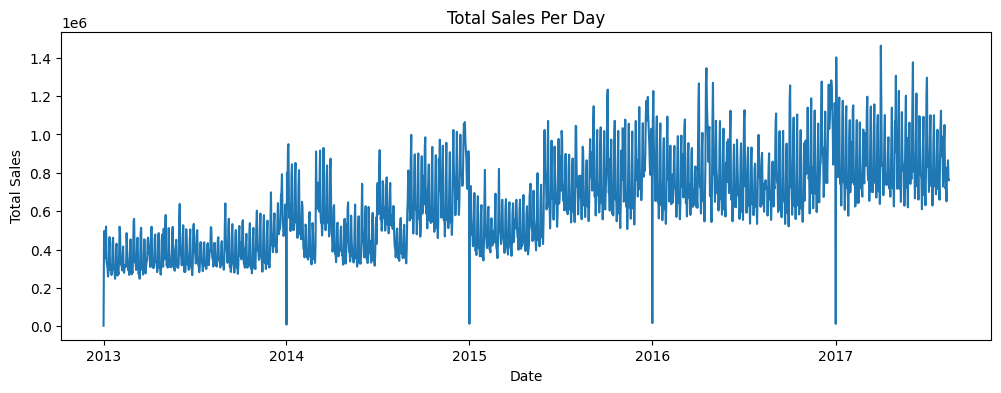

In [10]:
# converting the date from object to date
train['date'] = pd.to_datetime(train['date'])
train['date'].dtype

# build a daily total
total_sale_per_day = train.groupby('date')['sales'].sum()

# plot the result
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(total_sale_per_day)
plt.title('Total Sales Per Day')
plt.xlabel('Date')
plt.ylabel('Total Sales')

### Step 5 — Break it down.

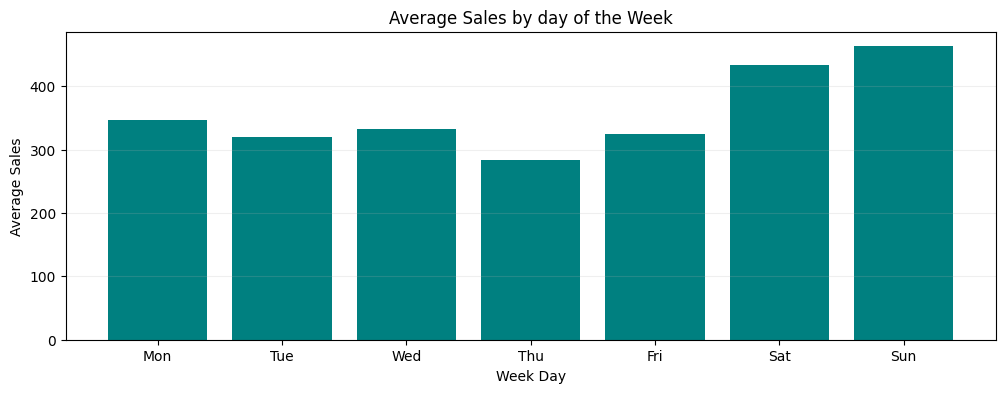

In [11]:
# create a day of week column
train['day_of_week'] = train['date'].dt.dayofweek

# group by the day of the week and get the average the sales
weekly_sales = train.groupby('day_of_week')['sales'].mean()

# define human readable labels matching 0-6 (Monday-Sunday)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot as a bar chart
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(day_labels, weekly_sales, color="teal")
plt.title('Average Sales by day of the Week')
plt.xlabel('Week Day')
plt.ylabel('Average Sales')
plt.grid(axis='y', alpha=0.2)

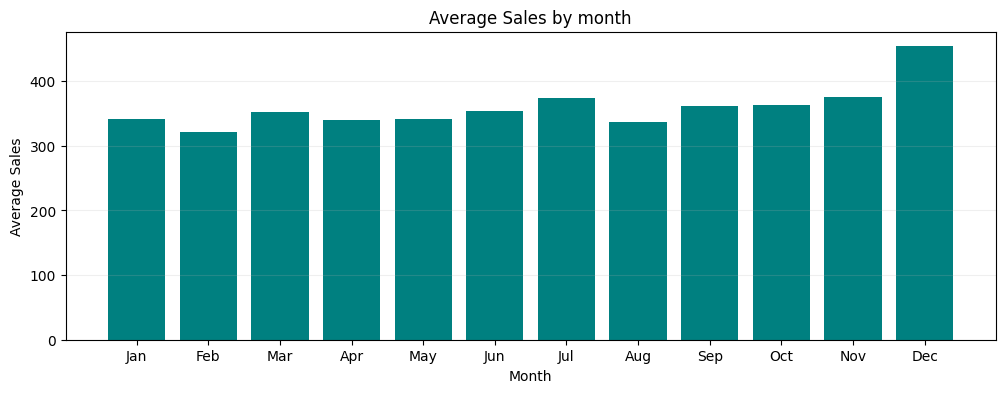

In [12]:
# create a day of week column
train['month'] = train['date'].dt.month

# group by the month and get the average the sales
monthly_sales = train.groupby('month')['sales'].mean()

# define human readable labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot as a bar chart
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(month_labels, monthly_sales, color="teal")
plt.title('Average Sales by month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(axis='y', alpha=0.2)

### Step 6 — Explore the helper files. 

In [13]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [14]:
# Create the holiday-closure table by combining all three conditions
holidays_clean = holidays[
    (holidays['transferred'] == False) & 
    (holidays['type'] != 'Work Day') & 
    (holidays['type'] != 'Event')
]

In [15]:
nat_holidays = holidays_clean[(holidays_clean['locale'] == 'National')].copy()
reg_holidays = holidays_clean[(holidays_clean['locale'] == 'Regional')].copy()
loc_holidays = holidays_clean[(holidays_clean['locale'] == 'Local')].copy()

# converting the date from object to date
nat_holidays['date'] = pd.to_datetime(nat_holidays['date'])
reg_holidays['date'] = pd.to_datetime(reg_holidays['date'])
loc_holidays['date'] = pd.to_datetime(loc_holidays['date'])

In [16]:
nat_merge = nat_holidays[['date']].copy()      # keep only the date column
nat_merge = nat_merge.drop_duplicates()        # one row per date, kills the duplication risk
nat_merge['is_national_holiday'] = 1 

reg_merge = reg_holidays[['date', 'locale_name']].copy()
reg_merge = reg_merge.drop_duplicates()
reg_merge['is_regional_holiday'] = 1

loc_merge = loc_holidays[['date', 'locale_name']].copy()
loc_merge = loc_merge.drop_duplicates()
loc_merge['is_local_holiday'] = 1

In [17]:
train = train.merge(stores, on='store_nbr', how='left')

train = train.merge(nat_merge, on='date', how='left')

In [18]:
train = train.merge(
    reg_merge,
    left_on=['date', 'state'],
    right_on=['date', 'locale_name'],
    how='left'
)

In [19]:
train['is_regional_holiday'].value_counts(dropna=False)

is_regional_holiday
NaN    2999865
1.0       1023
Name: count, dtype: int64

In [20]:
train = train.drop(columns=['locale_name'])

In [21]:
train = train.merge(
    loc_merge,
    left_on=['date', 'city'],
    right_on=['date', 'locale_name'],
    how='left'
)

In [22]:
holiday_cols = ['is_national_holiday', 'is_regional_holiday', 'is_local_holiday']
train[holiday_cols] = train[holiday_cols].fillna(0)

In [23]:
train['is_holiday'] = (
    (train['is_national_holiday'] == 1) |
    (train['is_regional_holiday'] == 1) |
    (train['is_local_holiday'] == 1)
).astype(int)

In [24]:
train[holiday_cols].sum()

is_national_holiday    138996.0
is_regional_holiday      1023.0
is_local_holiday        11880.0
dtype: float64

## Phase 3: A working baseline

### Step 7 — Build the simplest model that scores.

In [25]:
recent = train[train['date'] >='2017-07-31'].copy()
baseline_preds = recent.groupby(['store_nbr', 'family'])['sales'].mean().reset_index()

In [26]:
submission_df = test.merge(baseline_preds, on=['store_nbr', 'family'], how='left')
nan_count = submission_df['sales'].isna().sum()
print(f"nan count = {nan_count}")

if nan_count != 0:
    submission_df['sales'] = submission_df['sales'].fillna(0)

submission = submission_df[['id', 'sales']]
submission.to_csv('submission.csv', index=False)
submission.head()

nan count = 0


,id,sales
0,3000888,4.9375
1,3000889,0.0000
2,3000890,3.8750
3,3000891,2004.1250
4,3000892,0.0625


### Step 8 — Set up proper time-based validation.

## Phase 4: Feature engineering 

### Step 9 — Date features.

### Step 10 — Lag features. 

### Step 11 — Rolling window features.

### Step 12 — Merge in external data. 

## Phase 5: Real models

### Step 13 — Train a gradient boosting model. 

### Step 14 — Validate properly and iterate.

### Step 15 — Tune.